In [ ]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Desktop/UCLA/research/vectr/MinTimeQuadTraj`


In [ ]:
using LinearAlgebra
using Plots
using LaTeXStrings

In [3]:
using Revise
using MinTimeQuadTraj

In [33]:
h = 0.02

0.02

In [34]:
Nx = 5     # number of state
Nu = 2     # number of controls
tau_final = 1.0 # final time
Nt = Int(tau_final/h)+1   # number of time steps
thist = Array(range(0,h*(Nt-1), step=h));
n_nlp = 1 + (Nx+Nu)*Nt # number of decision variables, add 1 for the final time Tfinal
m_nlp = Nx*(Nt+1)
# m_nlp = Nx*(Nt+1) + 1 # account for two constraints on angle

260

In [35]:
function drone_dynamics(x, u, T)
    # x = [x, xdot, z, zdot, theta]
    # u = [uT, uR]
    xdot = x[2]
    zdot = x[4]
    return T * [xdot, u[1]*sin(x[5]), zdot, u[1]*cos(x[5]) - 1, u[2]]
end

drone_dynamics (generic function with 1 method)

In [36]:
function dircol_dynamics(x1,u1,x2,u2, T)
    #Hermite-Simpson integration with first-order hold on u
    f1 = drone_dynamics(x1, u1, T)
    f2 = drone_dynamics(x2, u2, T)
    xm = 0.5*(x1 + x2) + (h/8.0)*(f1 - f2)
    um = 0.5*(u1 + u2)
    ẋm = (-3/(2.0*h))*(x1 - x2) - 0.25*(f1 + f2)
    fm = drone_dynamics(xm, um, T)
    return fm - ẋm
end

dircol_dynamics (generic function with 1 method)

In [97]:
# Cost weights
Q = 1e-4 * Diagonal(ones(Nx));
R = 1e-4;

In [66]:
# original
function stage_cost_x_u(x,u)
    return 0.5*((x-xgoal)'*Q*(x-xgoal)) + 0.5*u'*R*u
end

function stage_cost_u(x,u)
    return 0.5*u'*R*u
end

function stage_cost_x(x,u)
    return 0.5*((x-xgoal)'*Q*(x-xgoal)) 
end

function stage_cost(x, u)
    return stage_cost_x_u(x,u)
end 

stage_cost (generic function with 1 method)

In [67]:
function cost_with_stage(ztraj)
    # account for final time 
    z = reshape(ztraj[2:end],Nx+Nu,Nt) # skip the first variable which is Tfinal
    J = 0.0
    for k = 1:Nt
        J += stage_cost(z[1:Nx,k],z[(Nx+1):(Nx+Nu),k]) 
    end
    return J + ztraj[1] # add final time to the cost
end

function cost_time_only(ztraj)
    return ztraj[1] # add final time to the cost
end

function cost(ztraj)
    return cost_with_stage(ztraj)
    # return cost_time_only(ztraj)
end

cost (generic function with 1 method)

In [68]:
function dynamics_constraint!(c,ztraj)
    # account for the final time variable
    Tfinal = ztraj[1]
    d = reshape(c,Nx,Nt-1)
    z = reshape(ztraj[2:end],Nx+Nu,Nt) # skip the first variable which is Tfinal
    for k = 1:(Nt-1)
        x1 = z[1:Nx,k]
        u1 = z[(Nx+1):(Nx+Nu),k]
        x2 = z[1:Nx,k+1]
        u2 = z[(Nx+1):(Nx+Nu),k+1]
        d[:,k] = dircol_dynamics(x1,u1,x2,u2, Tfinal)
    end
    return nothing
end

dynamics_constraint! (generic function with 1 method)

In [69]:
function con!(c,ztraj)
    z = reshape(ztraj[2:end], Nx+Nu, Nt) # skip first variable Tfinal
    c[1:Nx] .= z[1:Nx,1] - x0
    idx_dyn_start = Nx + 1
    idx_dyn_end = Nx + Nx*(Nt-1)
    @views dynamics_constraint!(c[idx_dyn_start:idx_dyn_end], ztraj)
    idx_term_start = idx_dyn_end + 1
    c[idx_term_start:(idx_term_start+Nx-1)] .= z[1:Nx,end] - xgoal
    return nothing
end

con! (generic function with 1 method)

In [70]:
g = 9.81
w = 10;           

In [71]:
#Initial and goal states
x0 = [0; 0; 0; 0; 0]
xgoal = [0; 0; 5 * w^2 / g; 0; 2*pi]

5-element Vector{Float64}:
  0.0
  0.0
 50.9683995922528
  0.0
  6.283185307179586

In [72]:
#Guess
xguess = kron(ones(Nt)', x0)
# xguess[1,:] .= xtraj[1,:] + 0.1*randn(Nt)
uguess = zeros(Nu, Nt)
# z0 = reshape([xguess; uguess],(Nx+Nu)*Nt,1);
Tguess = 10
z0 = [Tguess; reshape([xguess; uguess],(Nx+Nu)*Nt,1)];

In [73]:
prob = ProblemMOI(n_nlp,m_nlp, Nt, Nx, Nu, cost, con!; primal_bounds=primal_bounds(n_nlp, Nt, Nx, Nu, T_min=1.0e-3, g=9.81))

ProblemMOI{typeof(cost), typeof(con!)}(358, 260, 51, 5, 2, Main.cost, Main.con!, 1:0, true, true, [(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1)  …  (251, 358), (252, 358), (253, 358), (254, 358), (255, 358), (256, 358), (257, 358), (258, 358), (259, 358), (260, 358)], [(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1)  …  (251, 358), (252, 358), (253, 358), (254, 358), (255, 358), (256, 358), (257, 358), (258, 358), (259, 358), (260, 358)], ([0.001, -Inf, -Inf, -Inf, -Inf, -Inf, 0.1019367991845056, -1.0, -Inf, -Inf  …  -Inf, 0.1019367991845056, -1.0, -Inf, -Inf, -Inf, -Inf, -Inf, 0.1019367991845056, -1.0], [Inf, Inf, Inf, Inf, Inf, Inf, 2.038735983690112, 1.0, Inf, Inf  …  Inf, 2.038735983690112, 1.0, Inf, Inf, Inf, Inf, Inf, 2.038735983690112, 1.0]), ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0

In [ ]:
@btime z_sol = solve(z0,prob) # solve

In [99]:
# ztraj = reshape(z_sol,Nx+Nu,Nt)
# account for the final time variable
ztraj = reshape(z_sol[2:end],Nx+Nu,Nt) # skip the first variable which is Tfinal
xtraj = ztraj[1:Nx,:]
utraj = ztraj[(Nx+1):(Nx+Nu),:];

In [100]:
Tfinal = z_sol[1]
t_actual = thist * Tfinal / w
println("Optimal final time: ", Tfinal / w)

Optimal final time: 1.3012217920087812


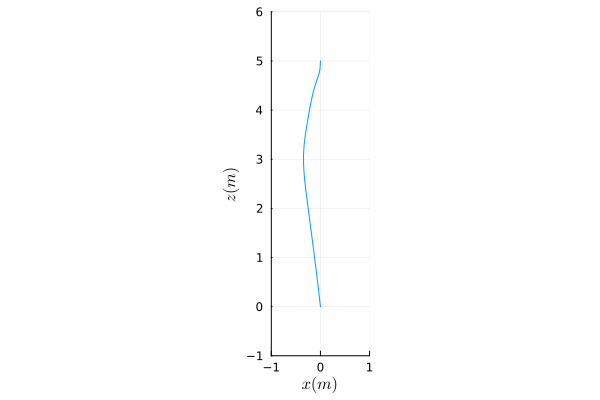

In [101]:
plot(xtraj[1,:]*g/w^2, xtraj[3,:]*g/w^2, aspect_ratio = :equal, legend = false)
xlims!(-1, 1)
xticks!(-1:1:1)
ylims!(-1, 6)
xlabel!(L"x(m)")
ylabel!(L"z(m)")
# savefig("traj_vert_h01_2pi.png")

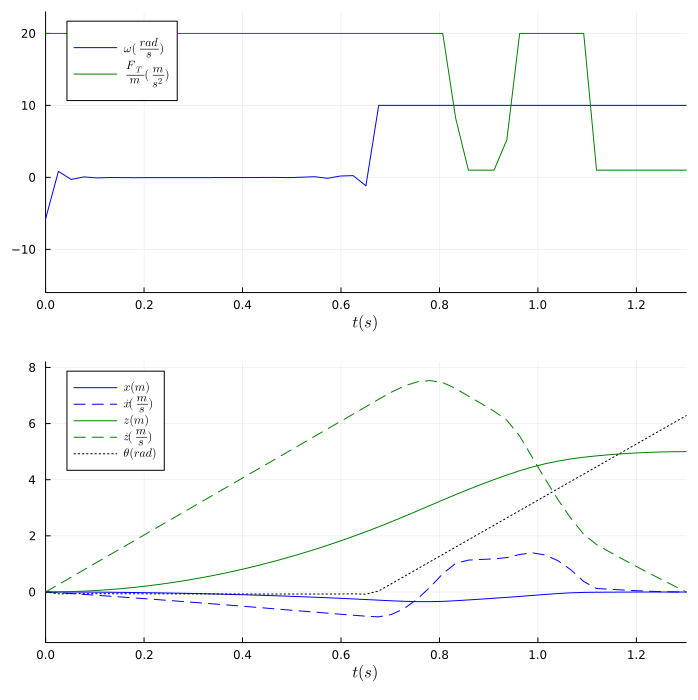

In [102]:
p1 = plot(t_actual,xtraj[1,:]*g/w^2, label=L"x(m)", xlabel=L"t(s)", color=:blue, legend=:topleft)
plot!(p1, t_actual,xtraj[2,:]*g/w, label=L"\dot{x}(\frac{m}{s})", color=:blue, linestyle=:dash)
plot!(p1, t_actual,xtraj[3,:]*g/w^2, label=L"z(m)", color=:green)
plot!(p1, t_actual,xtraj[4,:]*g/w, label=L"\dot{z}(\frac{m}{s})", color=:green, linestyle=:dash)
plot!(p1, t_actual,xtraj[5,:], label=L"\theta(rad)", color=:black, linestyle=:dot)
ylims!(p1, -1.8, 8.2)

p2 = plot(t_actual,utraj[2,:] * w, xlabel=L"t(s)", label=L"\omega(\frac{rad}{s})", legend=:topleft, color=:blue)
plot!(p2, t_actual,utraj[1,:] * g, label=L"\frac{F_T}{m}(\frac{m}{s^2})", color=:green)
ylims!(p2, -16, 23)

xlims!(p1, 0, t_actual[end])
xlims!(p2, 0, t_actual[end])
plot(p2, p1, layout = (2, 1), size=(700, 700))
# savefig("vert_states_h01_2pi.png")